# Pyomo.DoE: Multi-experiment design
Multi-experiment design is useful when several experiments can be run in parallel. Instead of designing one experiment at a time, we optimize multiple experiments together so that they provide complementary information about the model parameters. In Pyomo.DoE, this is done by maximizing a scalar function of the sum of the Fisher information matrices from each experiment, together with any prior information.

Maximize a scalar-valued function $\psi(\cdot)$ of the sum of the Fisher information matrices $\mathbf{M}$:
$$
\begin{align*}
\max_{u} \quad & \psi(\sum_{k\in E}\mathbf{M}_k(u_k) + \mathbf{M}_0) \\
\mathrm{s.t.} \quad & C_p^H \frac{dT_{H,k}}{dt} = U_a (T_{amb, k} - T_{H, k}) + U_b (T_{S,k} - T_{H,k}) + \alpha P u_k(t); \; \forall k \in E\\
& C_p^S \frac{dT_{S, k}}{dt} = U_b (T_{H,k} - T_{S,k}); \; \forall k \in E \\
& 0\% \leq u_k(t) \leq 100 \%; \; \forall k \in E\\
& T_{H,k}(t_0) = T_{amb, k}; \; \forall k \in E\\
& T_{S, k}(t_0) = T_{amb, k}; \; \forall k \in E
\end{align*}
$$
Here, $E=\{1, 2, ..., N_{exp}\}$ is the set of experiments in the experimental campaign.
`Pyomo.DoE` automatically formulates, initializes, and solves this optimization problem for 
- $\psi(\cdot) = \log_{10}(\mathrm{trace (FIM)})$, i.e., Pseudo A-optimality 
- $\psi(\cdot) = \log_{10}(\mathrm{trace (FIM^{-1})})$, i.e., A-optimality, and 
- $\psi(\cdot) = \log_{10}(\mathrm{det (FIM)})$, i.e., D-optimality.

In [21]:
import sys

# If running on Google Colab, install Pyomo and Ipopt via IDAES
on_colab = "google.colab" in sys.modules
if on_colab:
    !wget "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/notebooks/tclab_pyomo.py"

# import TCLab model, simulation, and data analysis functions
from tclab_pyomo import (
    TC_Lab_data,
    TC_Lab_experiment,
    extract_plot_results,
    results_summary,
)

# set default number of states in the TCLab model
number_tclab_states = 2

## Load experimental data (sine test)
We will load the sine test experimental data to serve as an initial point. 

In [22]:
import pandas as pd

if on_colab:
    file = "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/data/tclab_sine_test_5min_period.csv"
else:
    file = '../data/tclab_sine_test_5min_period.csv'
df = pd.read_csv(file)
df.head()

,Time,T1,T2,Q1,Q2
0,0.00,22.2,22.2,50,0
1,1.01,22.2,22.2,51,0
2,2.01,22.2,22.2,52,0
3,3.00,22.2,22.2,53,0
4,4.01,22.2,22.2,54,0


## Use prior parameter information
We will use the parameter estimates and covariance matrix obtained in the previous notebook. Since the Fisher information matrix (FIM) is the inverse of the covariance matrix, we can use that result as prior information for the new design problem.

In [23]:
# Load Pyomo.DoE class
from pyomo.contrib.doe import DesignOfExperiments

from pyomo.environ import SolverFactory

# From the experiment data (Copied from previous notebook)
theta_values = {
    'Ua': 0.0417051733576387,
    'Ub': 0.009440714239773074,
    'inv_CpH': 0.1659093525658045,
    'inv_CpS': 5.8357556063605465,
}

In [24]:
import numpy as np
cov = np.array([[2.437502e-10, 2.219941e-12, 5.154330e-09, -3.829830e-07],
                [2.219941e-12, 2.148727e-08, 1.199917e-08, -4.519563e-06],
                [5.154330e-09, 1.199917e-08, 3.356848e-07, -3.355975e-05],
                [-3.829830e-07, -4.519563e-06, -3.355975e-05, 4.421830e-03]])
FIM = np.linalg.inv(cov)/ 1e3
results_summary(FIM)

======Results Summary======
Four design criteria log10() value:
Pseudo A-optimality: 6.851471840244714
A-optimality: 0.6456371443783234
D-optimality: 15.259427090994143
E-optimality: -0.6456275144722733
Modified E-optimality: 7.490162987082787

FIM:
 [[ 6.97972578e+06 -1.49529515e+05 -2.34905496e+05 -1.33113699e+03]
 [-1.49529515e+05  9.64373659e+04  3.07092837e+04  3.18687822e+02]
 [-2.34905496e+05  3.07092837e+04  2.73258550e+04  2.18433679e+02]
 [-1.33113699e+03  3.18687822e+02  2.18433679e+02  2.09440582e+00]]

eigenvalues:
 [6.99093836e+06 1.01192735e+05 1.13597768e+04 2.26137447e-01]

Eigenvector matrix:
          eigvec_1  eigvec_2  eigvec_3  eigvec_4
Ua        -0.9992    0.0309   -0.0257   -0.0001
Ub         0.0218    0.9540    0.2991   -0.0010
inv_CpH    0.0338    0.2983   -0.9539   -0.0076
inv_CpS    0.0002    0.0032   -0.0069    1.0000


As in the [sequential design notebook](./doe_optimize_pseudo_A.ipynb), we will scale the parameters before solving the design problem because their nominal values differ substantially in magnitude. This improves numerical conditioning in `DesignOfExperiments`.

In [25]:
from pyomo.contrib.doe.utils import rescale_FIM
theta_ref = np.array([
    theta_values["Ua"],
    theta_values["Ub"],
    theta_values["inv_CpH"],
    theta_values["inv_CpS"],
])
# Using the rescaling function to scale the FIM with respect to the reference 
# theta values, so that we can use it in the DesignOfExperiments class.
FIM_scaled = rescale_FIM(FIM, theta_ref)
results_summary(FIM_scaled)

======Results Summary======
Four design criteria log10() value:
Pseudo A-optimality: 9.70722218265986
A-optimality: 2.1777962603575927
D-optimality: 22.09710159602377
E-optimality: -2.177796253923647
Modified E-optimality: 11.786497170584317

FIM:
 [[ 4.01290149e+09 -3.79780046e+08 -3.39494215e+07 -5.46935010e+03]
 [-3.79780046e+08  1.08202086e+09  1.96062242e+07  5.78446929e+03]
 [-3.39494215e+07  1.96062242e+07  9.92732004e+05  2.25606514e+02]
 [-5.46935010e+03  5.78446929e+03  2.25606514e+02  6.14988005e-02]]

eigenvalues:
 [4.06163522e+09 1.03383138e+09 4.48484279e+05 6.64054534e-03]

Eigenvector matrix:
          eigvec_1  eigvec_2  eigvec_3  eigvec_4
Ua        -0.9919    0.1266   -0.0070   -0.0000
Ub         0.1265    0.9918    0.0157   -0.0000
inv_CpH    0.0089    0.0147   -0.9999   -0.0002
inv_CpS    0.0000    0.0000   -0.0002    1.0000


## Initialize two experiments
We now create two experiment objects. The first uses the measured sine-test data, and the second uses a different initial input profile so that the optimizer can refine both experiments jointly.

In [26]:
from dataclasses import replace
# Create a new experiemnt object for design of experiments, using the same data and theta values as before
# Here, we will induce a step size of 15 seconds, as to make the optimization problem more tractable 

skip = 15

# Create the data object considering the new control points every 60 seconds
tc_data_1 = TC_Lab_data(
    name="Sine Wave Test for Heater 1",
    time=df['Time'].values[::skip],
    T1=df['T1'].values[::skip],
    u1=df['Q1'].values[::skip],
    P1=200,
    TS1_data=None,
    T2=df['T2'].values[::skip],
    u2=df['Q2'].values[::skip],
    P2=200,
    TS2_data=None,
    Tamb=df['T1'].values[0],
)

# Create experiment object for design of experiments
doe_experiment_1 = TC_Lab_experiment(
    data=tc_data_1,
    theta_initial=theta_values,
    number_of_states=number_tclab_states,
)


# Set a random seed for reproducibility
SEED: int = 11 # Choose any integer seed you like
PDF = "normal" # Choose between "normal" or "uniform" distribution for the new design of u1


def get_initial_u1_design(PDF="uniform", seed=11, sample_data = tc_data_1):
    rng = np.random.default_rng(seed=seed)
    if PDF == "normal":
        u1_design = rng.normal(loc=50.0, scale=10.0, size=len(sample_data.time))
        # Normal distribution is unbounded, so we need to clip the values to be within the 
        # bounds of the control input, which is [0, 100] in this case.
        u1_design = np.clip(u1_design, 0.0, 100.0)    
    elif PDF == "uniform":
        u1_design = rng.uniform(low=0.0, high=100.0, size=len(sample_data.time))

    # To break permutation symmetry, we can enforce that the first value of u1_design is greater than the first value of the original u1 data.
    if u1_design[0] <= sample_data.u1[0] and sample_data.u1[0] < 90.0:
        u1_design[0] = sample_data.u1[0] + 10.0
    else:
        u1_design[0] = 100.0

    # Create a new data object with only u1 replaced
    tc_data_new = replace(sample_data, u1=u1_design)
    return tc_data_new


tc_data_2 = get_initial_u1_design(PDF=PDF, seed=SEED, sample_data=tc_data_1)
# Build the experiment with the new design variable
doe_experiment_2 = TC_Lab_experiment(
    data=tc_data_2,
    theta_initial=theta_values,
    number_of_states=number_tclab_states,
)


## Optimize two experiments (D-optimality)
We now create a DesignOfExperiments object for the two experiments and choose a D-optimality objective. We also pass prior_FIM, which represents information already available from previous parameter estimation.

In [27]:

# Add a solver object to pass to DesignOfExperiments
solver = SolverFactory("ipopt")
solver.options["max_iter"] = 3000
solver.options["tol"] = 1e-6
solver.options["linear_solver"] = "ma57"
solver.options["nlp_scaling_method"] = "gradient-based"


# Create the design of experiments object using our experiment instance from above
TC_Lab_DoE_D = DesignOfExperiments(
    experiment=[doe_experiment_1, doe_experiment_2],  # We are optimizing two experiments simultaneously!
    step=1e-2,
    scale_constant_value=1,
    scale_nominal_param_value=True,
    objective_option="determinant",  # Now we specify a type of objective, D-opt = "determinant"
    prior_FIM=FIM_scaled,  # We use the prior information from the existing experiment!
    tee=True,
    solver=solver,
    # use_grey_box_objective=True,
    grey_box_tee = True,

)

TC_Lab_DoE_D.optimize_experiments()

Ipopt 3.13.2: max_iter=3000
tol=1e-06
linear_solver=ma57
nlp_scaling_method=gradient-based


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection

In [28]:
TC_Lab_DoE_D.results

{'problem': {'number_of_param_scenarios': 1,
  'number_of_experiments_per_scenario': 2,
  'used_template_experiment': False,
  'finite_difference_scheme': 'central',
  'finite_difference_step': 0.01,
  'scaled_nominal_parameters': True,
  'prior_fim': [[4012901489.9034967,
    -379780046.24989325,
    -33949421.48642541,
    -5469.350098353256],
   [-379780046.24989337,
    1082020863.8734803,
    19606224.232221577,
    5784.469288218594],
   [-33949421.48642547,
    19606224.23222159,
    992732.0041307438,
    225.60651446536815],
   [-5469.3500983532795,
    5784.4692882185955,
    225.60651446536818,
    0.06149880049809489]],
  'measurement_error_values': [np.float64(22.2),
   25.42371558456492,
   30.08990326461451,
   35.26472317488522,
   40.469114678146205,
   45.4702617385853,
   50.15485796941195,
   54.487216930677825,
   58.46317124702533,
   62.09800973830617,
   65.40408020537032,
   68.41798025854764,
   71.15421218614269,
   73.64332551876113,
   75.90112101762281,
  

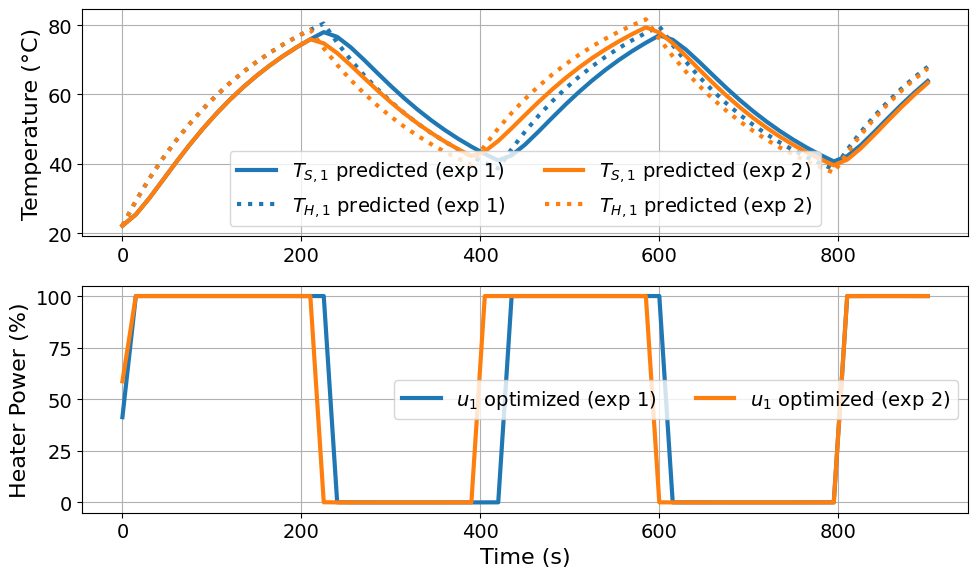

DoE optimize_experiments summary:
parameter scenario: 0
number of experiments: 2
objective: determinant
 


In [29]:
multiexp_results = extract_plot_results(None, TC_Lab_DoE_D)

In [30]:
FIM_D = np.asarray(TC_Lab_DoE_D.results["solution"]["param_scenarios"][0]['total_fim'])
D = np.diag(theta_ref)
FIM_unscaled_D = D @ FIM_D @ D
results_summary(np.asarray(FIM_unscaled_D))

======Results Summary======
Four design criteria log10() value:
Pseudo A-optimality: 6.904491227997828
A-optimality: -4.102829350577697
D-optimality: 21.981104505823208
E-optimality: 4.1686250432552105
Modified E-optimality: 2.6761253566172067

FIM:
 [[ 6.98309231e+06 -1.49527785e+05 -2.36170692e+05 -1.74318551e+03]
 [-1.49527785e+05  9.64394832e+04  3.08113137e+04  1.70160897e+03]
 [-2.36170692e+05  3.08113137e+04  3.69245915e+04  7.22153969e+04]
 [-1.74318551e+03  1.70160897e+03  7.22153969e+04  9.09397116e+05]]

eigenvalues:
 [6994398.94498187  915277.97563968  101432.24799333   14744.33002648]

Eigenvector matrix:
          eigvec_1  eigvec_2  eigvec_3  eigvec_4
Ua         0.9992   -0.0036    0.0312    0.0255
Ub        -0.0218   -0.0045    0.9507   -0.3092
inv_CpH   -0.0340   -0.0811    0.3070    0.9476
inv_CpS   -0.0007   -0.9967   -0.0294   -0.0759


In [44]:
cov_D = np.linalg.inv(FIM_unscaled_D)
print("Standard Deviations from Design D:")
for param, std in zip(theta_values.keys(), np.sqrt(np.diag(cov_D))):
    print(f"{param}: {std:.2e}")


Standard Deviations from Design D:
Ua: 4.43e-04
Ub: 3.92e-03
inv_CpH: 7.86e-03
inv_CpS: 1.22e-03


## Activity: Repeat the design with A-optimality
In this activity, we repeat the same workflow as above but change only the design objective. The repeated setup is shown again here so the section can be run independently.

In [32]:
import sys

# If running on Google Colab, install Pyomo and Ipopt via IDAES
on_colab = "google.colab" in sys.modules
if on_colab:
    !wget "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/notebooks/tclab_pyomo.py"

# import TCLab model, simulation, and data analysis functions
from tclab_pyomo import (
    TC_Lab_data,
    TC_Lab_experiment,
    extract_plot_results,
    results_summary,
)

# set default number of states in the TCLab model
number_tclab_states = 2

### Load the data
We will import the sine data for initializing the experiments.

In [33]:
import pandas as pd

if on_colab:
    file = "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/data/tclab_sine_test_5min_period.csv"
else:
    file = '../data/tclab_sine_test_5min_period.csv'
df = pd.read_csv(file)
df.head()

,Time,T1,T2,Q1,Q2
0,0.00,22.2,22.2,50,0
1,1.01,22.2,22.2,51,0
2,2.01,22.2,22.2,52,0
3,3.00,22.2,22.2,53,0
4,4.01,22.2,22.2,54,0


### Use the prior

In [34]:
import numpy as np
# Load Pyomo.DoE class
from pyomo.contrib.doe import DesignOfExperiments

from pyomo.environ import SolverFactory

# From the experiment data (Copied from previous notebook)
theta_values = {
    'Ua': 0.0417051733576387,
    'Ub': 0.009440714239773074,
    'inv_CpH': 0.1659093525658045,
    'inv_CpS': 5.8357556063605465,
}

cov = np.array([[2.437502e-10, 2.219941e-12, 5.154330e-09, -3.829830e-07],
                [2.219941e-12, 2.148727e-08, 1.199917e-08, -4.519563e-06],
                [5.154330e-09, 1.199917e-08, 3.356848e-07, -3.355975e-05],
                [-3.829830e-07, -4.519563e-06, -3.355975e-05, 4.421830e-03]])
FIM = np.linalg.inv(cov)/ 1e3
results_summary(FIM)

======Results Summary======
Four design criteria log10() value:
Pseudo A-optimality: 6.851471840244714
A-optimality: 0.6456371443783234
D-optimality: 15.259427090994143
E-optimality: -0.6456275144722733
Modified E-optimality: 7.490162987082787

FIM:
 [[ 6.97972578e+06 -1.49529515e+05 -2.34905496e+05 -1.33113699e+03]
 [-1.49529515e+05  9.64373659e+04  3.07092837e+04  3.18687822e+02]
 [-2.34905496e+05  3.07092837e+04  2.73258550e+04  2.18433679e+02]
 [-1.33113699e+03  3.18687822e+02  2.18433679e+02  2.09440582e+00]]

eigenvalues:
 [6.99093836e+06 1.01192735e+05 1.13597768e+04 2.26137447e-01]

Eigenvector matrix:
          eigvec_1  eigvec_2  eigvec_3  eigvec_4
Ua        -0.9992    0.0309   -0.0257   -0.0001
Ub         0.0218    0.9540    0.2991   -0.0010
inv_CpH    0.0338    0.2983   -0.9539   -0.0076
inv_CpS    0.0002    0.0032   -0.0069    1.0000


### Initialize two experiments
We will use the sine data and a randomly initialized data to design two experiments like before.

In [35]:
from dataclasses import replace
# Create a new experiemnt object for design of experiments, using the same data and theta values as before
# Here, we will induce a step size of 15 seconds, as to make the optimization problem more tractable 

skip = 15

# Create the data object considering the new control points every 60 seconds
tc_data_1 = TC_Lab_data(
    name="Sine Wave Test for Heater 1",
    time=df['Time'].values[::skip],
    T1=df['T1'].values[::skip],
    u1=df['Q1'].values[::skip],
    P1=200,
    TS1_data=None,
    T2=df['T2'].values[::skip],
    u2=df['Q2'].values[::skip],
    P2=200,
    TS2_data=None,
    Tamb=df['T1'].values[0],
)

# Create experiment object for design of experiments
doe_experiment_1 = TC_Lab_experiment(
    data=tc_data_1,
    theta_initial=theta_values,
    number_of_states=number_tclab_states,
)


# Set a random seed for reproducibility
SEED: int = 11 # Choose any integer seed you like
PDF = "normal" # Choose between "normal" or "uniform" distribution for the new design of u1


def get_initial_u1_design(PDF="uniform", seed=11, sample_data = tc_data_1):
    rng = np.random.default_rng(seed=seed)
    if PDF == "normal":
        u1_design = rng.normal(loc=50.0, scale=10.0, size=len(sample_data.time))
        # Normal distribution is unbounded, so we need to clip the values to be within the 
        # bounds of the control input, which is [0, 100] in this case.
        u1_design = np.clip(u1_design, 0.0, 100.0)    
    elif PDF == "uniform":
        u1_design = rng.uniform(low=0.0, high=100.0, size=len(sample_data.time))

    # To break permutation symmetry, we can enforce that the first value of u1_design is greater than the first value of the original u1 data.
    if u1_design[0] <= sample_data.u1[0] and sample_data.u1[0] < 90.0:
        u1_design[0] = sample_data.u1[0] + 10.0
    else:
        u1_design[0] = 100.0

    # Create a new data object with only u1 replaced
    tc_data_new = replace(sample_data, u1=u1_design)
    return tc_data_new


tc_data_2 = get_initial_u1_design(PDF=PDF, seed=SEED, sample_data=tc_data_1)
# Build the experiment with the new design variable
doe_experiment_2 = TC_Lab_experiment(
    data=tc_data_2,
    theta_initial=theta_values,
    number_of_states=number_tclab_states,
)


### Design the experiments

In [36]:
# Add a solver object to pass to DesignOfExperiments
solver = SolverFactory("ipopt")
solver.options["max_iter"] = 3000
solver.options["tol"] = 1e-6
solver.options["linear_solver"] = "ma57"
solver.options["nlp_scaling_method"] = "gradient-based"


# Create the design of experiments object using our experiment instance from above
TC_Lab_DoE_A = DesignOfExperiments(
    experiment=[doe_experiment_1, doe_experiment_2],  # We are optimizing two experiments simultaneously!
    step=1e-2,
    scale_constant_value=1,
    scale_nominal_param_value=True,
    objective_option="trace",  # Now we specify a type of objective, D-opt = "determinant"
    prior_FIM=FIM_scaled,  # We use the prior information from the existing experiment!
    tee=True,
    solver=solver,
    # use_grey_box_objective=True,
    grey_box_tee = True,

)

TC_Lab_DoE_A.optimize_experiments()

Ipopt 3.13.2: max_iter=3000
tol=1e-06
linear_solver=ma57
nlp_scaling_method=gradient-based


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection

In [37]:
TC_Lab_DoE_A.results

{'problem': {'number_of_param_scenarios': 1,
  'number_of_experiments_per_scenario': 2,
  'used_template_experiment': False,
  'finite_difference_scheme': 'central',
  'finite_difference_step': 0.01,
  'scaled_nominal_parameters': True,
  'prior_fim': [[4012901489.9034967,
    -379780046.24989325,
    -33949421.48642541,
    -5469.350098353256],
   [-379780046.24989337,
    1082020863.8734803,
    19606224.232221577,
    5784.469288218594],
   [-33949421.48642547,
    19606224.23222159,
    992732.0041307438,
    225.60651446536815],
   [-5469.3500983532795,
    5784.4692882185955,
    225.60651446536818,
    0.06149880049809489]],
  'measurement_error_values': [np.float64(22.2),
   24.027590717951163,
   26.57423802545391,
   29.27990121843354,
   31.87557013967596,
   34.24616771819691,
   36.35064378134513,
   38.19112058108912,
   39.785917163550224,
   41.16088796046254,
   42.340214462706754,
   43.35295897764742,
   44.2194873962018,
   44.96189875315828,
   45.59675387366712,
 

### Analyze the results

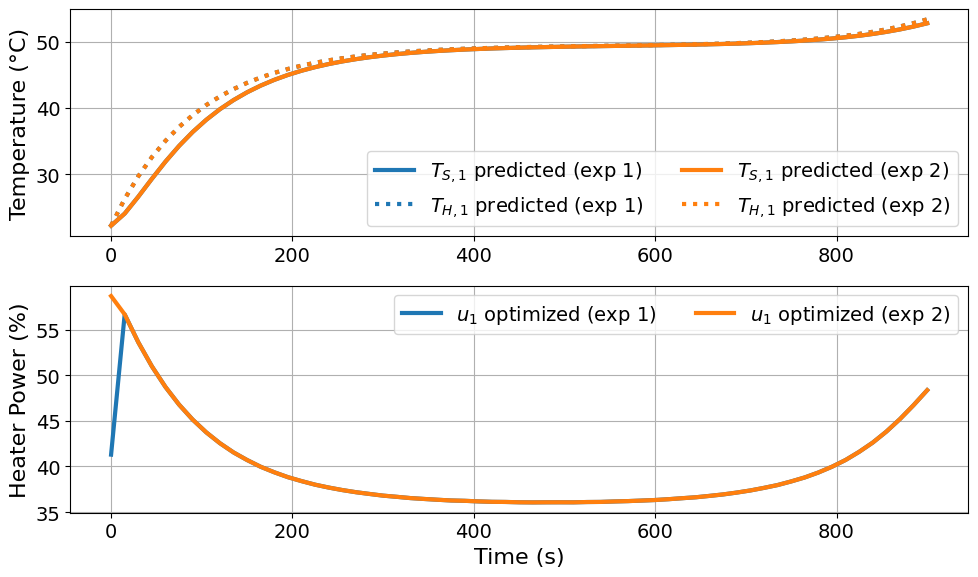

DoE optimize_experiments summary:
parameter scenario: 0
number of experiments: 2
objective: trace
 


In [38]:
multiexp_results = extract_plot_results(None, TC_Lab_DoE_A)

Convert the scaled FIM to unscaled FIM so that the comparison is fair.

In [39]:
FIM_A = np.asarray(TC_Lab_DoE_A.results["solution"]["param_scenarios"][0]['total_fim'])
D = np.diag(theta_ref)
FIM_unscaled_A = D @ FIM_A @ D
results_summary(np.asarray(FIM_unscaled_A))

======Results Summary======
Four design criteria log10() value:
Pseudo A-optimality: 6.856836440374612
A-optimality: -3.964707045588178
D-optimality: 20.847357667666174
E-optimality: 4.061259449786777
Modified E-optimality: 2.7833769823050094

FIM:
 [[ 6.98128694e+06 -1.49533922e+05 -2.35799989e+05 -4.98916065e+03]
 [-1.49533922e+05  9.64375408e+04  3.07239042e+04  4.40033727e+02]
 [-2.35799989e+05  3.07239042e+04  2.91271778e+04  1.10223423e+04]
 [-4.98916065e+03  4.40033727e+02  1.10223423e+04  8.49291185e+04]]

eigenvalues:
 [6992563.7120362    11514.88088491  102159.29321992   85542.88757336]

Eigenvector matrix:
          eigvec_1  eigvec_2  eigvec_3  eigvec_4
Ua         0.9992   -0.0255    0.0312   -0.0026
Ub        -0.0218    0.2962    0.9212   -0.2515
inv_CpH   -0.0339   -0.9447    0.3200    0.0626
inv_CpS   -0.0008    0.1383    0.2192    0.9658


In [45]:
cov_A = np.linalg.inv(FIM_unscaled_A)
print("Standard Deviations from Design A:")
for param, std in zip(theta_values.keys(), np.sqrt(np.diag(cov_A))):
    print(f"{param}: {std:.2e}")

Standard Deviations from Design A:
Ua: 4.57e-04
Ub: 4.08e-03
inv_CpH: 8.86e-03
inv_CpS: 3.61e-03


**Discussion**: How does changing the `objective` change the result? Which one is better for reducing the uncertainty in our experiment?